<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW2_Section_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laahir/MAT-422/blob/main/HW5/MAT422_HW2_Section_2_3.ipynb)

# MAT 422 - Homework 2 - Section 2.3: Joint Distributions, Correlation and Dependence, Random Samples

**Name:** Laahir
**Course:** MAT 422
**Topics covered:** joint probability distributions, correlation and dependence, random samples

Sticking with the same theme as my last couple homeworks, examples based on my job as a Math Instructional Aide. It's the dataset I actually understand best, so it made explaining these ideas a lot easier for me.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2.3.1 Joint Probability Distributions

A joint probability distribution tells you the probability of two things happening together, not just one at a time. Here I'm looking at two things about a student at once: how much practice they did before a quiz (low or high) and whether they passed the quiz (fail or pass).

I made up a table of counts out of 50 students I've tutored, then turned it into probabilities by dividing by the total.

In [2]:
# rows = practice level (low, high), columns = quiz outcome (fail, pass)
joint_counts = np.array([
    [9, 6],
    [3, 32],
])

total_students = joint_counts.sum()
joint_probability = joint_counts / total_students

print("joint probability table (rows: low/high practice, columns: fail/pass):")
print(joint_probability)
print("do all the joint probabilities add up to 1?", np.isclose(joint_probability.sum(), 1))

joint probability table (rows: low/high practice, columns: fail/pass):
[[0.18 0.12]
 [0.06 0.64]]
do all the joint probabilities add up to 1? True


In [3]:
# the marginal distribution for practice level: add across each row
marginal_practice = joint_probability.sum(axis=1)
print("marginal probability of practice level (low, high):", marginal_practice)

# the marginal distribution for quiz outcome: add down each column
marginal_outcome = joint_probability.sum(axis=0)
print("marginal probability of quiz outcome (fail, pass):", marginal_outcome)

print("\ndo the marginals also sum to 1?",
      np.isclose(marginal_practice.sum(), 1), np.isclose(marginal_outcome.sum(), 1))

marginal probability of practice level (low, high): [0.3 0.7]
marginal probability of quiz outcome (fail, pass): [0.24 0.76]

do the marginals also sum to 1? True True


The marginal distributions are just what you get if you stop caring about one of the two variables and only look at the other. Adding across a row of the joint table gives the overall probability of that practice level, no matter how the quiz turned out. This is a normal thing to do with a joint distribution, and it's a good sanity check since both marginals should also sum to 1 on their own.

## 2.3.2 Correlation and Dependence

Correlation measures how strongly two variables move together in a straight line kind of way. The Pearson correlation coefficient r ranges from -1 to 1, where 1 means perfectly increasing together, -1 means perfectly moving in opposite directions, and 0 means no linear relationship at all.

I'll compare two pairs of variables here: hours studied vs exam score, which I'd expect to be correlated, and two randomly generated variables that have nothing to do with each other, which should show close to no correlation.

In [4]:
np.random.seed(11)
hours = np.array([1, 2, 3, 3, 4, 5, 5, 6, 7, 8, 8, 9], dtype=float)
noise = np.random.randn(len(hours)) * 3
scores = 55 + 4 * hours + noise

r_studied, p_studied = stats.pearsonr(hours, scores)
print("correlation between hours studied and exam score: r =", r_studied)
print("p-value =", p_studied)

correlation between hours studied and exam score: r = 0.9540605397665671
p-value = 1.4915367986685007e-06


In [5]:
x_independent = np.random.randn(12)
y_independent = np.random.randn(12)

r_independent, p_independent = stats.pearsonr(x_independent, y_independent)
print("correlation between two unrelated random variables: r =", r_independent)

correlation between two unrelated random variables: r = -0.015169347776401235


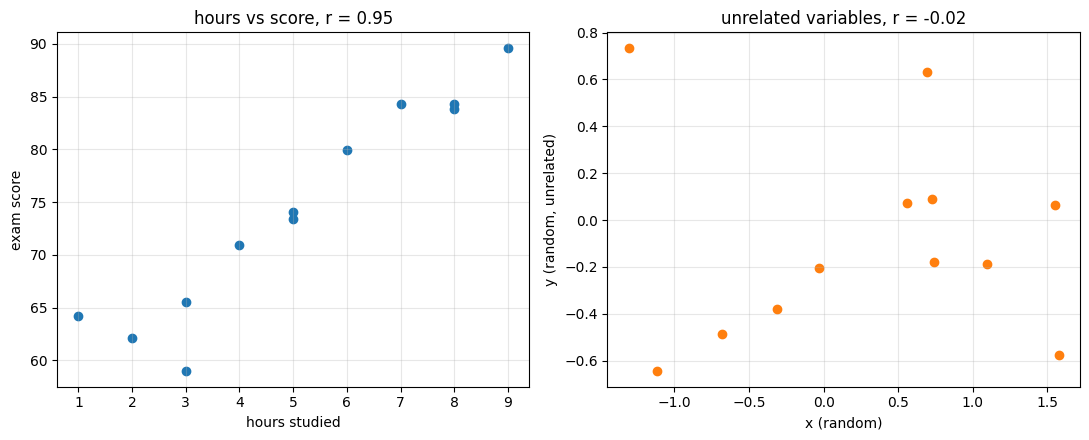

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(hours, scores, color="tab:blue")
axes[0].set_xlabel("hours studied")
axes[0].set_ylabel("exam score")
axes[0].set_title(f"hours vs score, r = {r_studied:.2f}")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_independent, y_independent, color="tab:orange")
axes[1].set_xlabel("x (random)")
axes[1].set_ylabel("y (random, unrelated)")
axes[1].set_title(f"unrelated variables, r = {r_independent:.2f}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The hours vs score plot shows a clear upward trend and an r close to 0.95, a strong positive correlation. The random pair on the right has an r close to 0, and the scatter just looks like a cloud with no pattern. That's what dependence looks like next to independence, one has a visible linear trend and a high r, the other doesn't have either.

## 2.3.3 Random Samples

A random sample is a subset pulled from a bigger population, where every member has some known chance of being picked. We use samples because we usually can't measure an entire population. Here I'll create a big fake population of exam scores, then repeatedly draw smaller random samples from it and look at how the sample means behave.

In [7]:
np.random.seed(21)
population = np.random.normal(75, 10, 5000)

print("population mean =", population.mean())
print("population standard deviation =", population.std())

one_sample = np.random.choice(population, size=30, replace=False)
print("\na single random sample of 30 scores, mean =", one_sample.mean())

population mean = 75.13609455806917
population standard deviation = 10.024266264791008

a single random sample of 30 scores, mean = 73.99005759395317


In [8]:
n_samples = 1000
sample_size = 30

sample_means = np.array([
    np.random.choice(population, size=sample_size, replace=False).mean()
    for _ in range(n_samples)
])

print("mean of 1000 sample means =", sample_means.mean())
print("standard deviation of the sample means =", sample_means.std())

predicted_std = population.std() / np.sqrt(sample_size)
print("predicted standard deviation, population_std divided by sqrt(sample size) =", predicted_std)

mean of 1000 sample means = 75.03030023850303
standard deviation of the sample means = 1.8289947008913483
predicted standard deviation, population_std divided by sqrt(sample size) = 1.83017225188803


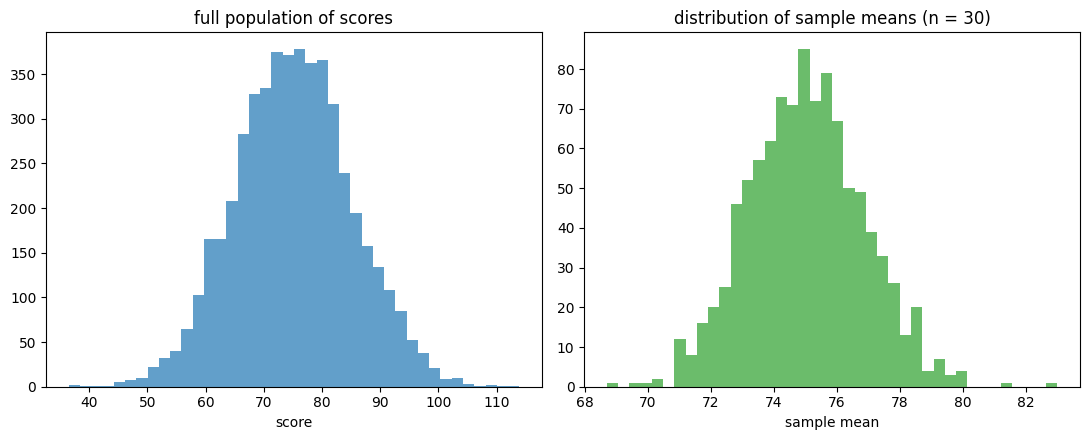

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(population, bins=40, color="tab:blue", alpha=0.7)
axes[0].set_title("full population of scores")
axes[0].set_xlabel("score")

axes[1].hist(sample_means, bins=40, color="tab:green", alpha=0.7)
axes[1].set_title("distribution of sample means (n = 30)")
axes[1].set_xlabel("sample mean")

plt.tight_layout()
plt.show()

The single sample mean landed close to the true population mean, which is what a random sample is supposed to give you on average. The bigger point is in the two histograms: the population itself is spread out a lot, but the distribution of sample means is much narrower and clustered tightly around 75. That matches the predicted standard deviation almost exactly, since averaging out a sample of 30 scores smooths out a lot of the individual variation, but the average itself still lands close to the true population mean most of the time.

## Reflection and Submission Checklist

- I explained each concept in my own words before showing the code.
- I checked my claims numerically instead of just trusting the math (joint probabilities and marginals summing to 1, comparing a correlated pair against an independent pair, the sample mean standard deviation matching the predicted formula).
- I used personal examples tied to my job as a Math Instructional Aide (practice level vs quiz outcome, hours studied vs exam score, sampling from a population of scores) instead of a generic textbook dataset.
- I ran every cell top to bottom in Colab with no errors.
- I saved this notebook directly from Google Colab to GitHub so the Open in Colab badge works.